# EEG Classification Results

Scatter plot of total recording duration versus the correct-class vote percentage for each subject.

## Assumptions

- The notebook searches `../results` for CSV files that look like subject-level trial summaries.
- Each usable CSV needs a subject column, a real-label column, and class vote columns or an equivalent correct-class vote column.
- If a duration column is missing, the notebook assumes 2.0 seconds per trial and uses `n_trials * 2.0`.
- If the same subject appears more than once, the notebook averages the values before plotting.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path("../results/eegformer_5fold_run/subject_trial_stats_5fold.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"CSV file not found: {csv_path}")

csv_files = [csv_path]
output_dir = csv_path.parent

print(f"Using CSV file: {csv_path}")

Using CSV file: ../results/eegformer_5fold_run/subject_trial_stats_5fold.csv


In [4]:
def normalize_label(value):
    text = str(value).strip().lower()
    if text in {"1", "adhd", "case", "patient"} or "adhd" in text:
        return "ADHD"
    if text in {"0", "control", "hc", "healthy"} or "control" in text or "healthy" in text or "hc" in text:
        return "Control"
    return np.nan

rows = []
for path in csv_files:
    df = pd.read_csv(path)
    df.columns = [str(col).strip() for col in df.columns]

    subject_col = next((col for col in ["subject", "subject_id"] if col in df.columns), None)
    label_col = next((col for col in ["label", "real_label", "y_true"] if col in df.columns), None)
    class0_col = next((col for col in ["trial_pct_class0", "vote_pct_0", "vote_pct_control", "false_class_vote_pct"] if col in df.columns), None)
    class1_col = next((col for col in ["trial_pct_class1", "vote_pct_1", "vote_pct_adhd", "true_class_vote_pct"] if col in df.columns), None)
    duration_col = next((col for col in ["trial_duration", "duration_seconds", "duration"] if col in df.columns), None)
    trials_col = next((col for col in ["n_trials", "n_epochs"] if col in df.columns), None)

    if subject_col is None or label_col is None or (class0_col is None and class1_col is None):
        continue

    data = pd.DataFrame({
        "subject": df[subject_col].astype(str),
        "real_label": df[label_col].map(normalize_label),
        "vote_pct_control": pd.to_numeric(df[class0_col], errors="coerce") if class0_col is not None else np.nan,
        "vote_pct_adhd": pd.to_numeric(df[class1_col], errors="coerce") if class1_col is not None else np.nan,
    })

    for col in ["vote_pct_control", "vote_pct_adhd"]:
        vote_values = data[col].dropna()
        if not vote_values.empty and vote_values.between(0, 1).all():
            data[col] = data[col] * 100.0

    data["correct_vote_pct"] = np.where(
        data["real_label"] == "ADHD",
        data["vote_pct_adhd"],
        data["vote_pct_control"],
    )

    if duration_col is not None:
        data["duration_seconds"] = pd.to_numeric(df[duration_col], errors="coerce")
    elif trials_col is not None:
        data["duration_seconds"] = pd.to_numeric(df[trials_col], errors="coerce") * 2.0
    else:
        data["duration_seconds"] = np.nan

    rows.append(data)

if not rows:
    raise ValueError("No usable subject-level CSV files were found in results/.")

data = pd.concat(rows, ignore_index=True)
data = data.dropna(subset=["subject", "real_label", "correct_vote_pct"])
data = data[data["real_label"].isin(["Control", "ADHD"])]

subject_data = (
    data.groupby("subject", as_index=False)
    .agg(
        real_label=("real_label", "first"),
        duration_seconds=("duration_seconds", "mean"),
        correct_vote_pct=("correct_vote_pct", "mean"),
    )
    .dropna(subset=["duration_seconds", "correct_vote_pct"])
)

print(subject_data.head().to_string(index=False))
print()
print(subject_data["real_label"].value_counts().to_string())

 subject real_label  duration_seconds  correct_vote_pct
v107.mat    Control             306.0         97.385621
v108.mat    Control             294.0         99.319728
v109.mat    Control             248.0        100.000000
v10p.mat       ADHD             220.0         83.636364
v110.mat    Control             256.0        100.000000

real_label
ADHD       61
Control    59


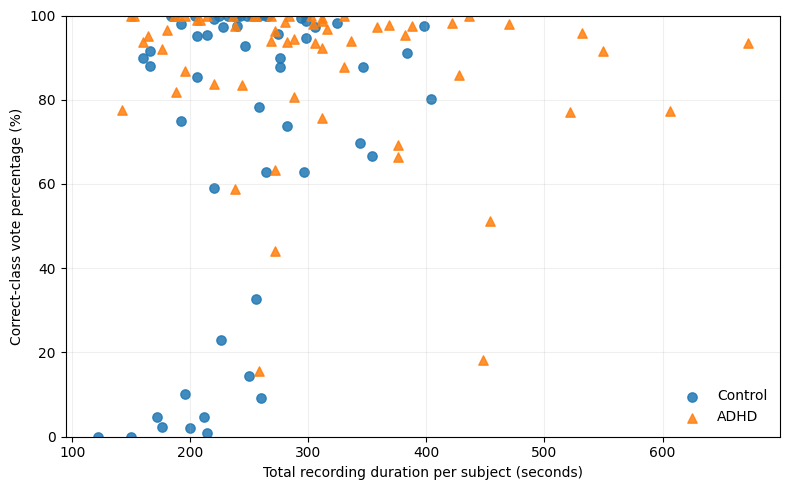

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

groups = {
    "Control": {"color": "tab:blue", "marker": "o"},
    "ADHD": {"color": "tab:orange", "marker": "^"},
}

for label, style in groups.items():
    subset = subject_data[subject_data["real_label"] == label]
    ax.scatter(
        subset["duration_seconds"],
        subset["correct_vote_pct"],
        label=label,
        color=style["color"],
        marker=style["marker"],
        s=45,
        alpha=0.85,
    )

ax.set_xlabel("Total recording duration per subject (seconds)")
ax.set_ylabel("Correct-class vote percentage (%)")
ax.set_ylim(0, 100)
ax.legend(frameon=False)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

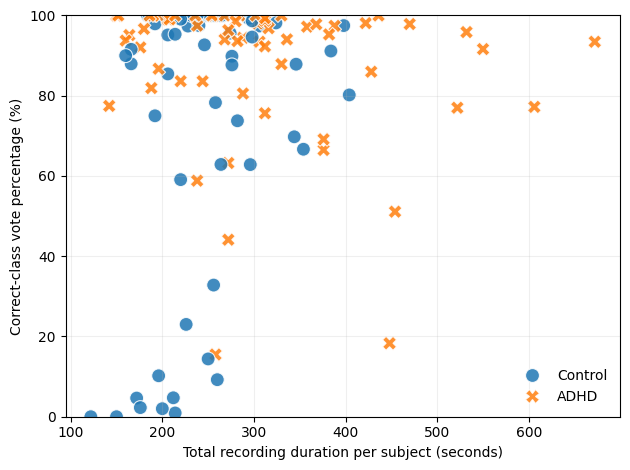

In [ ]:
import seaborn as sns

sns.scatterplot(data=subject_data, x="duration_seconds", y="correct_vote_pct", hue="real_label", style="real_label", s=100, alpha=0.85)
plt.xlabel("Total recording duration per subject (seconds)")
plt.ylabel("Correct-class vote percentage (%)")
plt.ylim(0, 100)
plt.legend(frameon=False)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
r2_value = np.corrcoef(subject_data["duration_seconds"], subject_data["correct_vote_pct"])[0, 1] ** 2
print(f"R² value for duration vs. correct vote percentage: {r2_value:.4f}")

R² value for duration vs. correct vote percentage: 0.0180


In [5]:
subject_data.to_csv(output_dir / "subject_level_summary.csv", index=False)
print(f"Saved: {output_dir / 'subject_level_summary.csv'}")

Saved: ../results/eegformer_5fold_run/subject_level_summary.csv
